In [179]:
import pandas as pd
import seaborn as sns
import numpy as np
from numpy.ma.core import shape
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split 
from sklearn.naive_bayes import CategoricalNB, GaussianNB
from sklearn.metrics import accuracy_score, classification_report, roc_curve


In [23]:
spam = pd.read_csv('./dataset/spambase.csv')

In [6]:
print(spam.shape)
spam.head()

(4601, 55)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_edu,word_freq_table,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,spam
0,0,640,640,0,320,0,0,0,0,0,...,0,0,0,0,0,0,778,0,0,1
1,210,280,500,0,140,280,210,70,0,940,...,0,0,0,0,132,0,372,180,48,1
2,60,0,710,0,1230,190,190,120,640,250,...,60,0,0,10,143,0,276,184,10,1
3,0,0,0,0,630,0,310,630,310,630,...,0,0,0,0,137,0,137,0,0,1
4,0,0,0,0,630,0,310,630,310,630,...,0,0,0,0,135,0,135,0,0,1


In [7]:
spam.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_edu,word_freq_table,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,spam
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,104.553358,213.014345,280.656379,65.424908,312.222995,95.900891,114.207564,105.294501,90.067377,239.413171,...,179.823734,5.444469,31.869159,38.574440,139.030428,16.975875,269.068898,75.810259,44.237992,0.394045
std,305.357562,1290.574888,504.142884,1395.151370,672.511666,273.824083,391.440302,401.071452,278.615864,644.755399,...,911.118627,76.274271,285.734646,243.470469,270.355374,109.394164,815.669848,245.879440,429.341596,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,65.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,420.000000,0.000000,380.000000,0.000000,0.000000,0.000000,0.000000,160.000000,...,0.000000,0.000000,0.000000,0.000000,188.000000,0.000000,315.000000,52.000000,0.000000,1.000000
max,4540.000000,14280.000000,5100.000000,42810.000000,10000.000000,5880.000000,7270.000000,11110.000000,5260.000000,18180.000000,...,22050.000000,2170.000000,10000.000000,4385.000000,9752.000000,4081.000000,32478.000000,6003.000000,19829.000000,1.000000


In [62]:
freq_words_spam = pd.DataFrame(spam[spam['spam'] == 1].apply(np.sum, axis=0).sort_values(ascending=False, inplace=False)[:10])
freq_words_no_spam = pd.DataFrame(spam[spam['spam'] == 0].apply(np.sum, axis=0).sort_values(ascending=False, inplace=False)[:10])

Text(0.5, 1.0, '10 palabras mas comunes en correos spam')

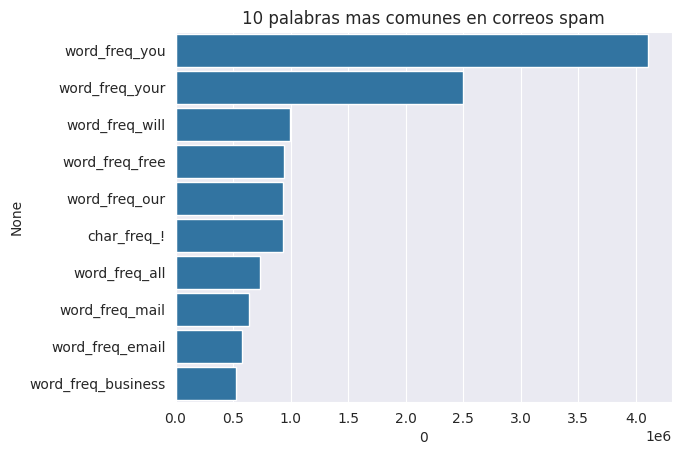

In [60]:
p = sns.barplot(freq_words_spam, x=0, y=freq_words_spam.index, width=0.9, orient='h')
p.set_title("10 palabras mas comunes en correos spam")

Text(0.5, 1.0, '10 palabras mas comunes en correos spam')

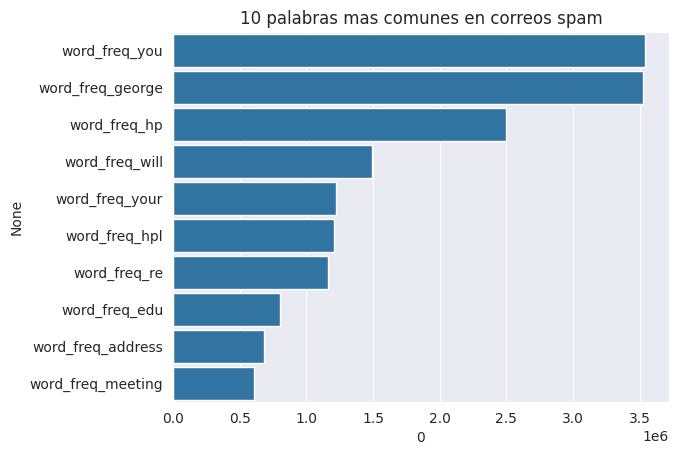

In [63]:
p = sns.barplot(freq_words_no_spam, x=0, y=freq_words_no_spam.index, width=0.9, orient='h')
p.set_title("10 palabras mas comunes en correos spam")

In [47]:
freq_words_spam[:, 0:10]

KeyError: (slice(None, None, None), slice(0, 10, None))

In [67]:
X_train, X_test, y_train, y_test = train_test_split(spam.drop(columns=['spam']),spam["spam"], test_size=0.3, random_state=0)


In [115]:
bayes = GaussianNB().fit(X_train, y_train)

In [116]:
print(classification_report(bayes.predict(X_train), y_train))

              precision    recall  f1-score   support

           0       0.73      0.97      0.83      1491
           1       0.96      0.70      0.81      1729

    accuracy                           0.82      3220
   macro avg       0.85      0.83      0.82      3220
weighted avg       0.85      0.82      0.82      3220



In [117]:
print(classification_report(bayes.predict(X_test), y_test))

              precision    recall  f1-score   support

           0       0.72      0.94      0.81       626
           1       0.93      0.69      0.79       755

    accuracy                           0.80      1381
   macro avg       0.82      0.81      0.80      1381
weighted avg       0.83      0.80      0.80      1381



In [120]:
logit = LogisticRegression().fit((X_train - X_train.mean())/X_train.std() , y_train)

In [122]:
print(classification_report(logit.predict((X_train - X_train.mean())/X_train.std()), y_train))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94      2025
           1       0.89      0.93      0.91      1195

    accuracy                           0.93      3220
   macro avg       0.92      0.93      0.93      3220
weighted avg       0.93      0.93      0.93      3220



In [123]:
print(classification_report(logit.predict((X_test - X_test.mean())/X_test.std()), y_test))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       845
           1       0.86      0.90      0.88       536

    accuracy                           0.90      1381
   macro avg       0.90      0.90      0.90      1381
weighted avg       0.90      0.90      0.90      1381



In [163]:
def _confusion_matrix(y_test, y_pred):
    false_positive = sum((y_test == 0) & y_pred == 1)
    false_negative = sum((y_test == 1) & y_pred == 0)
    true_positive = sum((y_test == 1) & y_pred == 1)
    true_negative = sum((y_test == 0) & y_pred == 0)
    return [false_positive, true_negative, false_negative, true_positive]
def confusion_matrix(y_test, y_pred):
    cm_data = _confusion_matrix(y_test, y_pred)
    return pd.DataFrame(np.array([cm_data[:2], cm_data[2:]]), columns = ["pred_positive", "pred_negative"], index=["negative", "positive"])

In [166]:
confusion_bayes =  confusion_matrix(bayes.predict(X_test), y_test)
confusion_bayes

,pred_positive,pred_negative
negative,38,1343
positive,860,521


In [167]:
confusion_logit = confusion_matrix(logit.predict(X_test), y_test)
confusion_logit

,pred_positive,pred_negative
negative,36,1345
positive,858,523


AttributeError: 'list' object has no attribute 'split'

# Punto 5

El error mas comun para ambos modelos es el falso negativo, es decir, correos que eran spam pero no se detectaron como tal. 

Si bien los correos spam presentan una amenaza de seguridad el error mas importante para este problema es el falso positivo ya que se podria estar filtrando un mail importante y generar un daño al usuario.
  

In [175]:
# precision = cantidad de correo spam detectado como spam / cantidad de correo detectado como spam 
# precision = verdaderos positivos / (verdaderos positivos + falsos positivos)

def precision(confusion_matrix):
    return confusion_matrix.loc["positive"]["pred_positive"] / (confusion_matrix.loc["positive"]["pred_positive"] + confusion_matrix.loc["negative"]["pred_positive"])

# recall = cantidad de correo spam detectado como spam / cantidad de correo spam 
# precision = verdaderos positivos / (verdaderos positivos + falsos negativo)
def recall(confusion_matrix):
    return confusion_matrix.loc["positive"]["pred_positive"] / (confusion_matrix.loc["positive"]["pred_positive"] + confusion_matrix.loc["positive"]["pred_negative"])


In [176]:
print(precision(confusion_bayes))
print(recall(confusion_bayes))

0.9576837416481069
0.6227371469949312


In [173]:
print(precision(confusion_logit))
print(recall(confusion_logit))

0.959731543624161
0.6212889210716872


# Punto 6

Como nos interesa estar seguro que, si se detecto un correo como spam, ese correo sea efectivamente spam, la metrica de precision es la mas valiosa para nosotros ya que si da 1 todos los correos que se marcaron como spam son, en efecto, spam.

En este sentido ambos modelos se comportan muy parecido.

In [180]:
roc_curve(y_test, logit.predict(X_test))

(array([0.        , 0.16301703, 1.        ]),
 array([0.        , 0.93559928, 1.        ]),
 array([inf,  1.,  0.]))

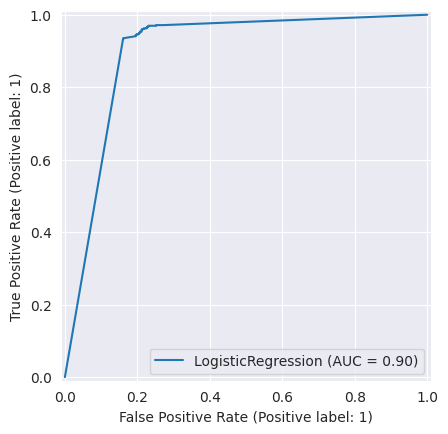

In [182]:
from sklearn.metrics import RocCurveDisplay

svc_disp = RocCurveDisplay.from_estimator(logit, X_test, y_test)


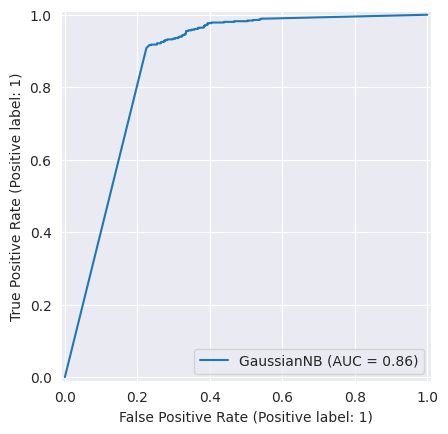

In [183]:
svc_disp = RocCurveDisplay.from_estimator(bayes, X_test, y_test)
